# Segmentación de clientes con K-Means

En este documento puedes desarrollar el eunciado adjunto (contiene algunas pistas y preguntas adicionales)

## Objetivos
- Comprender qué es clustering.
- Aplicar K-Means.
- Elegir el número óptimo de clusters.
- Interpretar los resultados.

## Pregunta Inicial
**¿Podemos identificar tipos de clientes según su comportamiento?**
- Si, podemos identificar tipos de clientes según su comportamiento gracias al spending score, que puede significar que si el puntuaje es alto, puede gastar mucho en relacion con su ingresión, y de menor puntuaje puede significar todo lo contrario.

## Descripción de las columnas
- **CustomerID**: Identificador único de cada cliente. No es relevante para el clustering, ya que no aporta información útil para la segmentación.
- **Genre**: Género del cliente (Male/Female). En algunos casos puede ser útil si se convierte a valores numéricos, aunque K-Means trabaja mejor con variables numéricas continuas.
- **Age**: Edad del cliente. Puede ser un factor clave en la segmentación, ya que distintos grupos de edad pueden tener diferentes patrones de gasto.
- **Annual Income (k$)**: Ingreso anual del cliente en miles de dólares. Es un indicador relevante para clasificar clientes en función de su poder adquisitivo.
- **Spending Score (1-100)**: Puntuación asignada a cada cliente según sus hábitos de gasto y comportamiento de compra (por ejemplo, un puntaje alto puede indicar que el cliente gasta mucho en relación con su ingreso).

## 1. Carga de datos

In [21]:

import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("ClientesCentroComercial.csv")
df.tail()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18
199,200,Male,30,137,83


## 2. Exploración inicial

In [ ]:
# Con info mostramos que tipo de datos tenemos en el dataset. Observamos que tenemos 4 tipos de datos numericos y uno categorico.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
# Con describe podemos observar la media, el maximo; de cada una de las columnas (entre varias medidas), pero en este caso me parecen las mas importantes a simple vista, ya que con ellas podemos detectar 
# que hay que escalar si o si (aparte de que habia que hacerlo porque es K-Means y va en base a distancias).
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


## Cuestiones
1. ¿Qué variables te parecen más útiles para agrupar clientes?
Las variables que me parecen mas utiles son: Age, Annual Income (k$), Spending Score (1-100). Ya que se puede dividir muy bien en grupos de años, porque entre rangos suelen tener un comportamiento parecido.
Lo mismo para las otras dos variables; la gente que cobra en rangos parecidos suelen tener comportamientos parecidos, salvo excepciones.
2. ¿Hay alguna variable que no tenga sentido usar?
La unica variable que no tiene sentido usar es CustomerID, no nos ayuda a agrupar en grupos, no tiene informacion valiosa, y menos para intentar predecir, son datos concretos de este dataset, pero si queremos ver más alla, con datos nuevos, no tendría sentido alguno.

## 3. Selección de variables

Vamos a trabajar con dos variables especialmente útiles para segmentar clientes:
- **Annual Income (k$)**
- **Spending Score (1-100)**

In [4]:

X = df[["Annual Income (k$)", "Spending Score (1-100)"]]
X.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


**Recuerda:** estamos usando variables relacionadas con capacidad económica y comportamiento de compra.

## 4. Visualización inicial

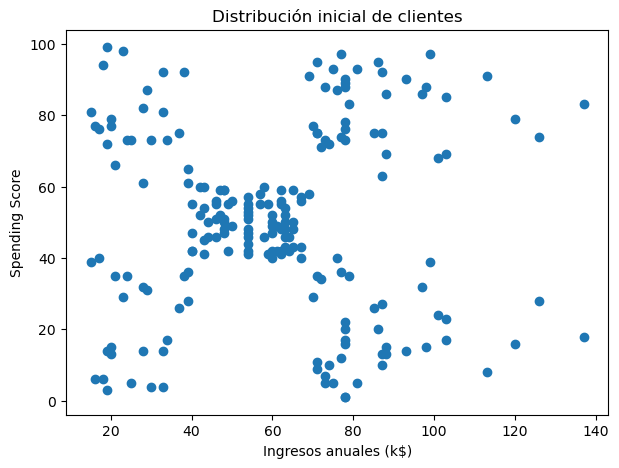

In [5]:

plt.figure(figsize=(7,5))
plt.scatter(X.iloc[:, 0], X.iloc[:, 1])
plt.xlabel("Ingresos anuales (k$)")
plt.ylabel("Spending Score")
plt.title("Distribución inicial de clientes")
plt.show()

## Cuestión
**¿Observas posibles grupos de clientes a simple vista?**
- Puede llegar a observar 5 o 3 grupos. Tendría mas sentido 5 grupos ya que separaria mejor en "circulos" en un intervalo de spending score corto. Si se dividiesen en 3 grupos tendria que aguparse (a primera vista) todos los puntos que hay de 0 a 100 de spending score, y eso se tendría que hacer en dos situaciones.


## 5. Escalado de datos

**Importante:** K-Means utiliza distancias.  
Por eso, antes de aplicar el algoritmo, conviene poner las variables en la misma escala.

In [6]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# COMPLETAR
X_scaled = scaler.fit_transform(X)

## 6. Método del codo

Ahora vamos a probar distintos valores de **K** para decidir cuántos clusters conviene usar.

In [7]:

from sklearn.cluster import KMeans

inercia = []

for k in range(1, 11):
    modelo = KMeans(n_clusters=k, random_state=42, n_init=10)

    # COMPLETAR
    modelo.fit(X_scaled)

    inercia.append(modelo.inertia_)

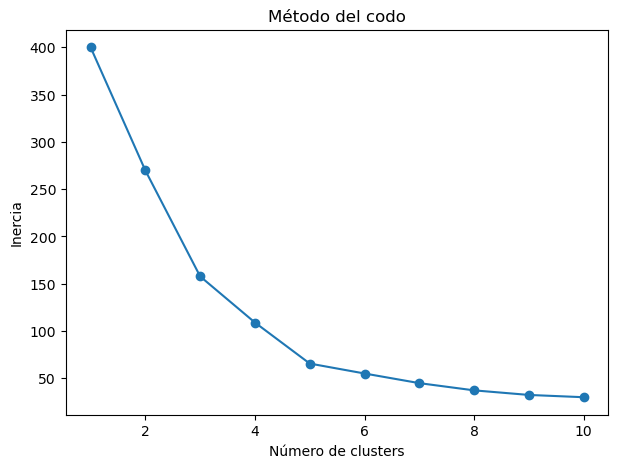

In [8]:

plt.figure(figsize=(7,5))
plt.plot(range(1, 11), inercia, marker="o")
plt.xlabel("Número de clusters")
plt.ylabel("Inercia")
plt.title("Método del codo")
plt.show()

## Cuestiones
1. ¿En qué valor de **K** parece producirse el “codo”?
- Se ve en el valor 5.
2. ¿Por qué ese punto puede considerarse un buen compromiso?
- Es un buen punto ya que menos, la pendiente sigue siendo notable y más clusteres se queda casi en linea recta.

## 7. Aplicación de K-Means

In [15]:
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

# COMPLETAR
clusters = kmeans.fit_predict(X_scaled)

## 8. Visualización de clusters

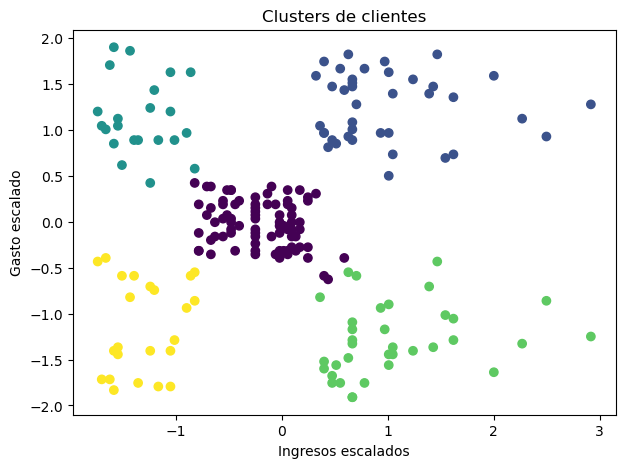

In [16]:

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters de clientes")
plt.show()

## 9. Centroides

In [ ]:

centroides = kmeans.cluster_centers_

plt.figure(figsize=(7,5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.scatter(centroides[:, 0], centroides[:, 1], marker="X", s=200)
plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Clusters con centroides")
plt.show()

## 10. Interpretación de resultados

Añade una nueva columna al DataFrame con el cluster asignado a cada cliente.

In [17]:

# COMPLETAR
df["cluster"] = clusters
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,2
2,3,Female,20,16,6,4
3,4,Female,23,16,77,2
4,5,Female,31,17,40,4


In [18]:

df.groupby("cluster")[["Annual Income (k$)", "Spending Score (1-100)"]].mean()

,Annual Income (k$),Spending Score (1-100)
cluster,,
0,55.296296,49.518519
1,86.538462,82.128205
2,25.727273,79.363636
3,88.200000,17.114286
4,26.304348,20.913043


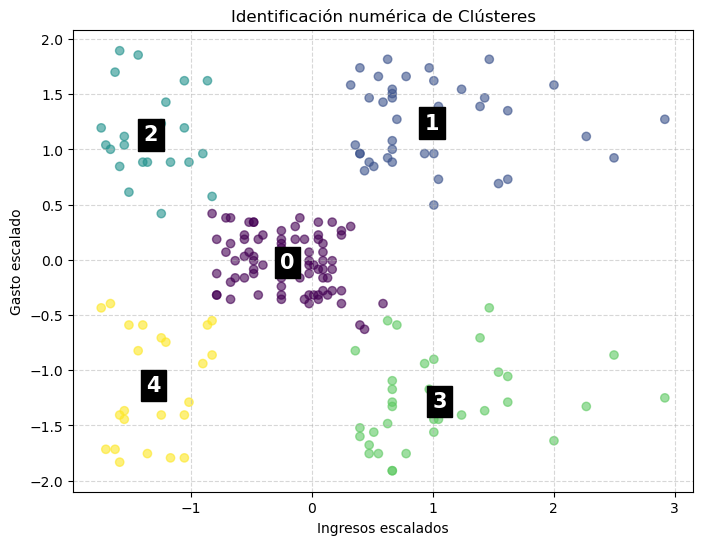

In [ ]:
import matplotlib.pyplot as plt

# 1. Obtenemos los centros de los clusters
centros = kmeans.cluster_centers_

plt.figure(figsize=(8, 6))

# 2. Graficamos los puntos coloreados por cluster
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters, cmap='viridis', alpha=0.6)

# 3. Dibujamos el número de cada cluster en su centroide
for i, punto_central in enumerate(centros):
    plt.annotate(str(i), 
                 (punto_central[0], punto_central[1]),
                 fontsize=15, 
                 weight='bold', 
                 color='white',
                 backgroundcolor='black',
                 ha='center', 
                 va='center')

plt.xlabel("Ingresos escalados")
plt.ylabel("Gasto escalado")
plt.title("Identificación numérica de Clústeres")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Cuestiones
1. ¿Qué tipo de clientes representa cada cluster?
- El cluster 0: Representa "Clientes promedio", lo que significa que tienen unos ingresos y unos gastos medios.
- El cluster 1: Representa "Clientes premium", lo que significa que tienen unos ingresos altos y a la par, unos gastos también.
- El cluster 2: Representa "Clientes derrochadores", lo que significa que tienen unos ingresos bajos pero gastan mucho.
- El cluster 3: Representa "Clientes ahorradores", lo que significa que tienen un ingresos altos pero no gastan mucho.
- El cluster 4: Representa "Clientes limitados", lo que significa que tienen ingresos bajos y a la par, gastan poco.
2. ¿Cuál te parece más interesante para el negocio?
- El cluster que me parece más interesante es el 3, ya que es un grupo de personas, el cual tienen unos ingresos altos pero gastan poco, hay bastantes rango de mejora (más probabilidad de que gaste más). - - -  Enfocandonos en priorizar a ese grupo. 
3. ¿Qué estrategia comercial podría aplicarse a cada grupo?
- Para el cluster 0 (Clientes promedio): Pequeñas ofertas, para intentar atraer a que gasten más.
- Para el cluster 1 (Clientes premium): Rebajas por cantidad de productos comprados, como son un grupo que parece que no les importa mucho gastar, poner rebajas si superan cierto numero de productos o cierta cantidad de €.
- Para el cluster 2 (Clientes derrochadores): No me centrarian tanto en ellos porque son los clientes que gastan casi más de lo que tienen, son derrochadores de por sí.
- Para el cluster 3 (Clientes ahorradores): Son en los que más me enfocarían, ya que tienen el dinero para gastar pero no lo hacen, les haría las ofertas más llamativas y grandes.
- Para el cluster 4 (Clientes limitados): Alguna pequeña oferta, pero tampoco me centraría en ellos porque son los que menor ingresos tienen.
4. ¿Qué pasaría si no hubiéramos escalado los datos?
5. ¿K-Means siempre encuentra los mejores grupos?
6. ¿Qué limitaciones tiene este algoritmo?

## 11. Opcional

Prueba a repetir el análisis añadiendo la variable **Age**.

Preguntas:
- ¿Cambian los clusters?
- ¿Son más realistas o más difíciles de interpretar?